In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.8 MB/s eta 0:00:00


In [2]:
import os
import shutil
import yaml
import cv2
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pathlib import Path
from collections import Counter, defaultdict
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
KAGGLE_INPUT = Path('/kaggle/input/urban-issues-dataset')
KAGGLE_WORKING = Path('/kaggle/working')

# Check dataset structure
print("📁 Dataset structure:")
print(f"Input path: {KAGGLE_INPUT}")
print(f"Working path: {KAGGLE_WORKING}")

# List available datasets
print("\n📦 Available datasets:")
for item in os.listdir('/kaggle/input'):
    print(f"  - {item}")

📁 Dataset structure:
Input path: /kaggle/input/urban-issues-dataset
Working path: /kaggle/working

📦 Available datasets:
  - urban-issues-dataset


In [4]:
dataset_path = KAGGLE_INPUT

print("\n🔍 Exploring dataset structure:")
for root, dirs, files in os.walk(dataset_path):
    print(f"\n{root}")
    for d in dirs[:5]:
        print(f"  📁 {d}")
    if files:
        print(f"  📄 {len(files)} files")
    if len(dirs) > 5:
        print(f"  ... and {len(dirs)-5} more directories")


🔍 Exploring dataset structure:

/kaggle/input/urban-issues-dataset
  📁 FallenTrees
  📁 DamagedElectricalPoles
  📁 DamagedRoadSigns
  📁 IllegalParking
  📁 Graffitti
  📄 1 files
  ... and 4 more directories

/kaggle/input/urban-issues-dataset/FallenTrees
  📁 FallenTrees

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees
  📁 valid
  📁 test
  📁 train

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/valid
  📁 labels
  📁 images

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/valid/labels
  📄 982 files

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/valid/images
  📄 982 files

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/test
  📁 labels
  📁 images

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/test/labels
  📄 1632 files

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/test/images
  📄 1632 files

/kaggle/input/urban-issues-dataset/FallenTrees/FallenTrees/train
  📁 labels
  📁 images

/kaggle/input/urban-issues-da

In [5]:
class YOLODatasetAnalyzer:
    """Comprehensive YOLO dataset analyzer for EDA"""
    
    def __init__(self, dataset_path, class_names):
        self.dataset_path = Path(dataset_path)
        self.class_names = class_names
        self.stats = defaultdict(list)

    def find_images_and_labels(self):
        """Find all images and labels in dataset"""
        self.image_files = []
        self.label_files = []

        # Search for images
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
            self.image_files.extend(list(self.dataset_path.rglob(ext)))

        # Search for labels
        self.label_files = list(self.dataset_path.rglob('*.txt'))

        print(f"Found {len(self.image_files)} images")
        print(f"Found {len(self.label_files)} label files")

        return self.image_files, self.label_files

    def analyze_dataset(self):
        """Perform comprehensive EDA"""
        self.find_images_and_labels()

        class_counts = Counter()
        bbox_counts = []
        image_with_labels = 0
        bbox_sizes = []

        for label_file in tqdm(self.label_files, desc="Analyzing labels"):
            try:
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                    if lines:
                        image_with_labels += 1
                        bbox_counts.append(len(lines))

                        for line in lines:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                class_id = int(parts[0])
                                class_counts[class_id] += 1
                                w, h = float(parts[3]), float(parts[4])
                                bbox_sizes.append((w, h))
            except Exception as e:
                print(f"Error reading {label_file}: {e}")

        self.class_counts = class_counts
        self.bbox_counts = bbox_counts
        self.bbox_sizes = bbox_sizes

        return class_counts, bbox_counts, bbox_sizes

    def visualize_analysis(self):
        """Create comprehensive visualizations"""
        fig = plt.figure(figsize=(20, 12))

        # 1. Class Distribution
        plt.subplot(2, 3, 1)
        classes = [self.class_names[i] for i in sorted(self.class_counts.keys())]
        counts = [self.class_counts[i] for i in sorted(self.class_counts.keys())]

        plt.barh(classes, counts, color='steelblue')
        plt.xlabel('Number of Instances', fontsize=12)
        plt.title('Class Distribution', fontsize=14, fontweight='bold')

        for i, v in enumerate(counts):
            plt.text(v, i, f' {v}', va='center', fontsize=10)

        # 2. Class Distribution Pie Chart
        plt.subplot(2, 3, 2)
        plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90)
        plt.title('Class Distribution (%)', fontsize=14, fontweight='bold')

        # 3. Objects per Image
        plt.subplot(2, 3, 3)
        plt.hist(self.bbox_counts, bins=30, color='coral', edgecolor='black')
        plt.xlabel('Number of Objects per Image', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title(f'Objects per Image\n(Avg: {np.mean(self.bbox_counts):.2f})',
                  fontsize=14, fontweight='bold')

        # 4. Bounding Box Width Distribution
        plt.subplot(2, 3, 4)
        widths = [w for w, h in self.bbox_sizes]
        plt.hist(widths, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
        plt.xlabel('Normalized Width', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Bounding Box Width Distribution', fontsize=14, fontweight='bold')

        # 5. Bounding Box Height Distribution
        plt.subplot(2, 3, 5)
        heights = [h for w, h in self.bbox_sizes]
        plt.hist(heights, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
        plt.xlabel('Normalized Height', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Bounding Box Height Distribution', fontsize=14, fontweight='bold')

        # 6. Summary Statistics
        plt.subplot(2, 3, 6)
        plt.axis('off')

        total_images = len(self.image_files)
        total_labels = len(self.label_files)
        total_objects = sum(counts)

        summary_text = f"""
        📊 DATASET SUMMARY
        {'='*40}

        Total Images: {total_images}
        Total Label Files: {total_labels}
        Total Objects: {total_objects}

        Number of Classes: {len(self.class_counts)}

        Avg Objects/Image: {np.mean(self.bbox_counts):.2f}
        Max Objects/Image: {max(self.bbox_counts)}
        Min Objects/Image: {min(self.bbox_counts)}

        Most Common Class: 
        {self.class_names[max(self.class_counts, key=self.class_counts.get)]}
        ({max(counts)} instances)

        Least Common Class: 
        {self.class_names[min(self.class_counts, key=self.class_counts.get)]}
        ({min(counts)} instances)
        """

        plt.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center')

        plt.tight_layout()
        plt.savefig(KAGGLE_WORKING / 'eda_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        return {
            'total_images': total_images,
            'total_objects': total_objects,
            'class_counts': self.class_counts,
        }

    def visualize_samples(self, num_samples=6):
        """Visualize random samples with annotations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.ravel()

        samples = random.sample(self.image_files, min(num_samples, len(self.image_files)))
        colors = plt.cm.tab10(np.linspace(0, 1, len(self.class_names)))

        for idx, img_path in enumerate(samples):
            # Find corresponding label
            label_path = img_path.with_suffix('.txt')
            if not label_path.exists():
                label_path = Path(str(img_path).replace('images', 'labels').replace(img_path.suffix, '.txt'))

            # Read image
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]

            # Draw annotations
            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            x_center, y_center, width, height = map(float, parts[1:5])

                            # Convert to pixel coordinates
                            x1 = int((x_center - width/2) * w)
                            y1 = int((y_center - height/2) * h)
                            x2 = int((x_center + width/2) * w)
                            y2 = int((y_center + height/2) * h)

                            # Draw bbox
                            color = (np.array(colors[class_id][:3]) * 255).astype(int)
                            cv2.rectangle(img, (x1, y1), (x2, y2), color.tolist(), 2)

                            # Add label
                            label = self.class_names[class_id]
                            cv2.putText(img, label, (x1, y1-10),
                                      cv2.FONT_HERSHEY_SIMPLEX, 0.5, color.tolist(), 2)

            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(f'Sample {idx+1}', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.savefig(KAGGLE_WORKING / 'sample_images.png', dpi=300, bbox_inches='tight')
        plt.show()


🔍 Analyzing dataset...
Found 47140 images
Found 47142 label files


Analyzing labels:  41%|████      | 19278/47142 [01:04<01:29, 310.45it/s]

Error reading /kaggle/input/urban-issues-dataset/DamagedRoadSigns/DamagedRoadSigns/README.dataset.txt: invalid literal for int() with base 10: '#'
Error reading /kaggle/input/urban-issues-dataset/DamagedRoadSigns/DamagedRoadSigns/README.roboflow.txt: invalid literal for int() with base 10: 'damaged'


Analyzing labels:  46%|████▌     | 21621/47142 [01:12<01:21, 311.87it/s]

Error reading /kaggle/input/urban-issues-dataset/IllegalParking/IllegalParking/README.dataset.txt: invalid literal for int() with base 10: '#'
Error reading /kaggle/input/urban-issues-dataset/IllegalParking/IllegalParking/README.roboflow.txt: invalid literal for int() with base 10: 'Illegal'


Analyzing labels: 100%|██████████| 47142/47142 [02:37<00:00, 299.46it/s]



📊 Visualizing analysis...


/tmp/ipykernel_19/2733297224.py:138: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19/2733297224.py:139: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(KAGGLE_WORKING / 'eda_analysis.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


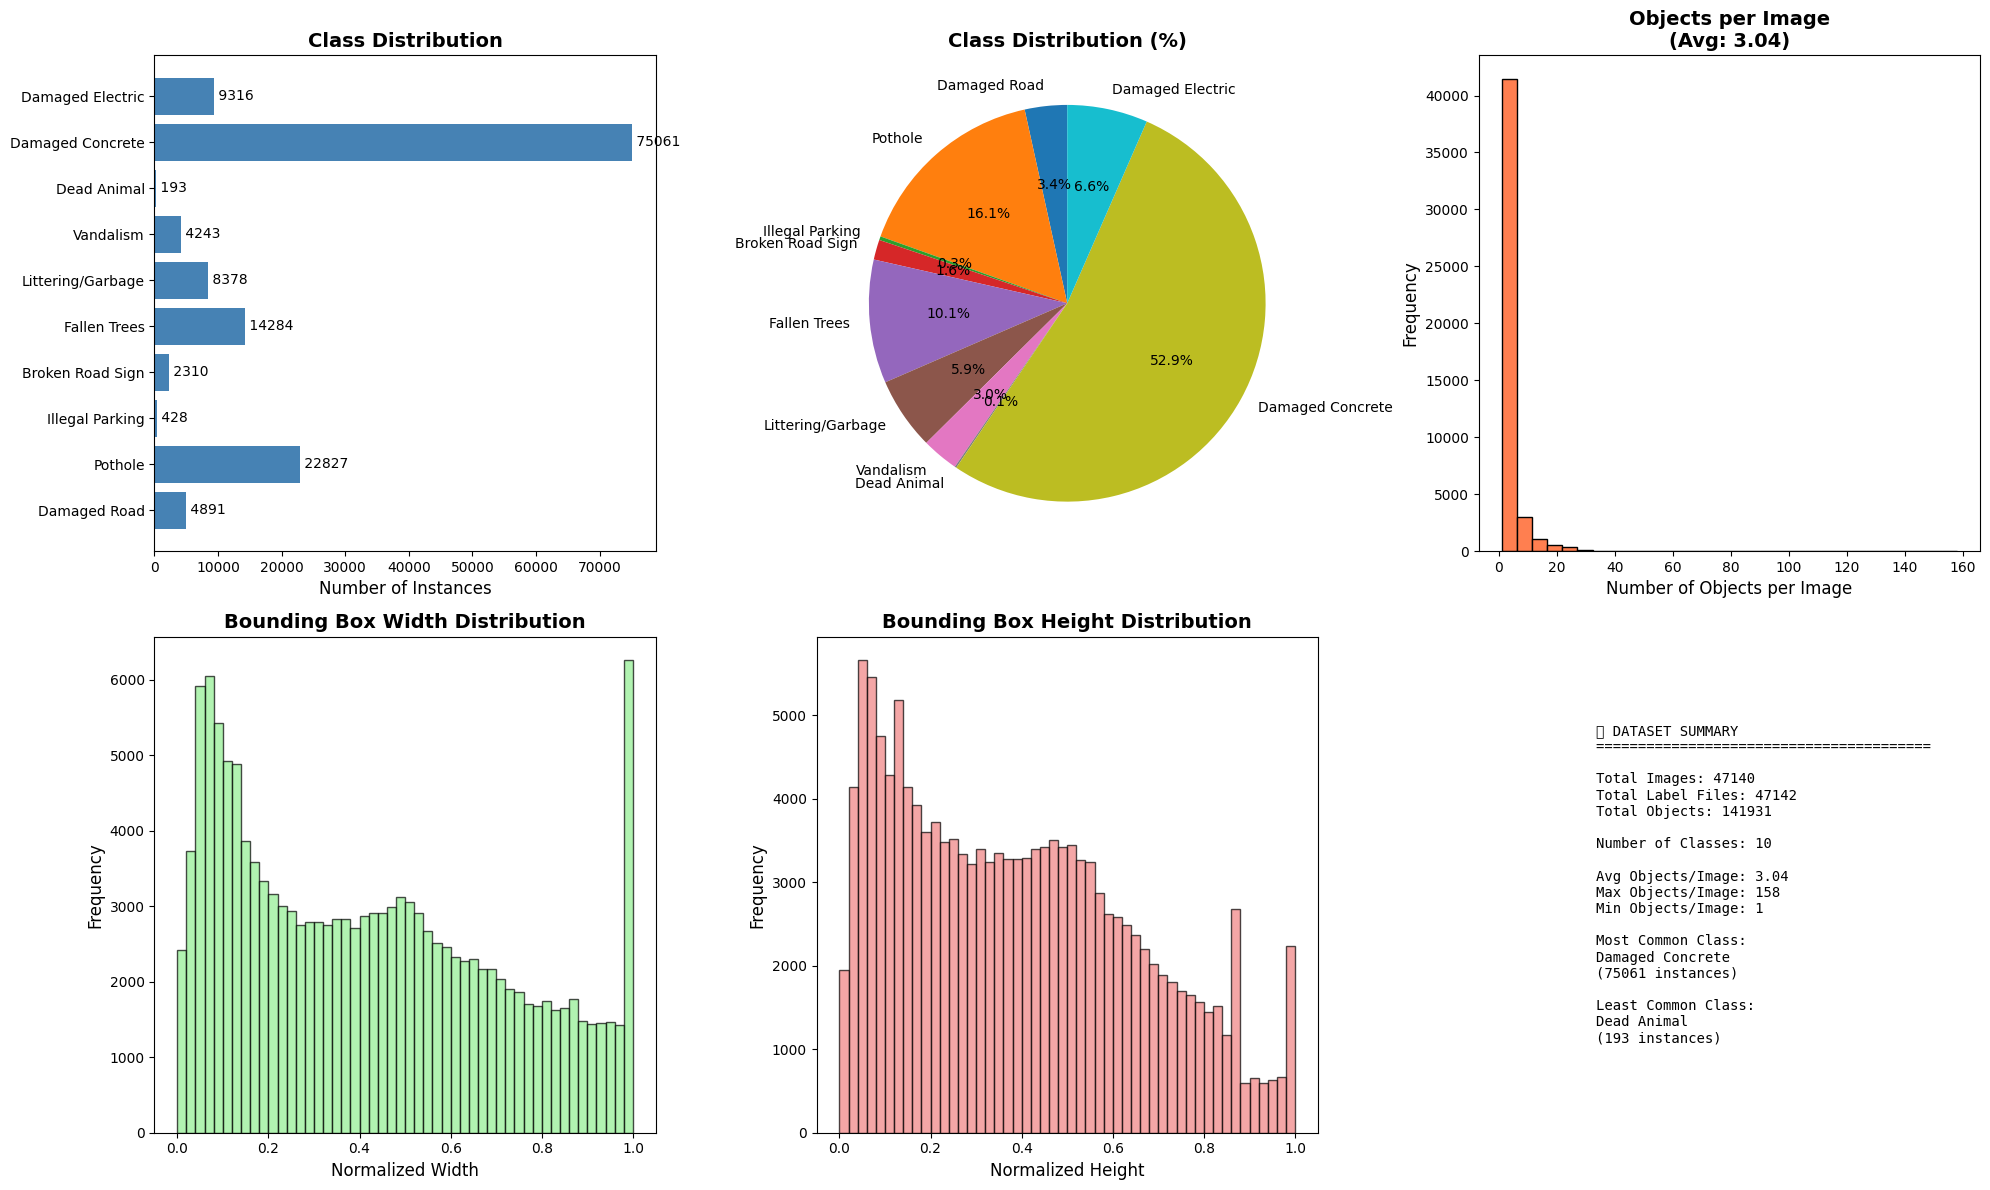


🖼️ Visualizing samples...


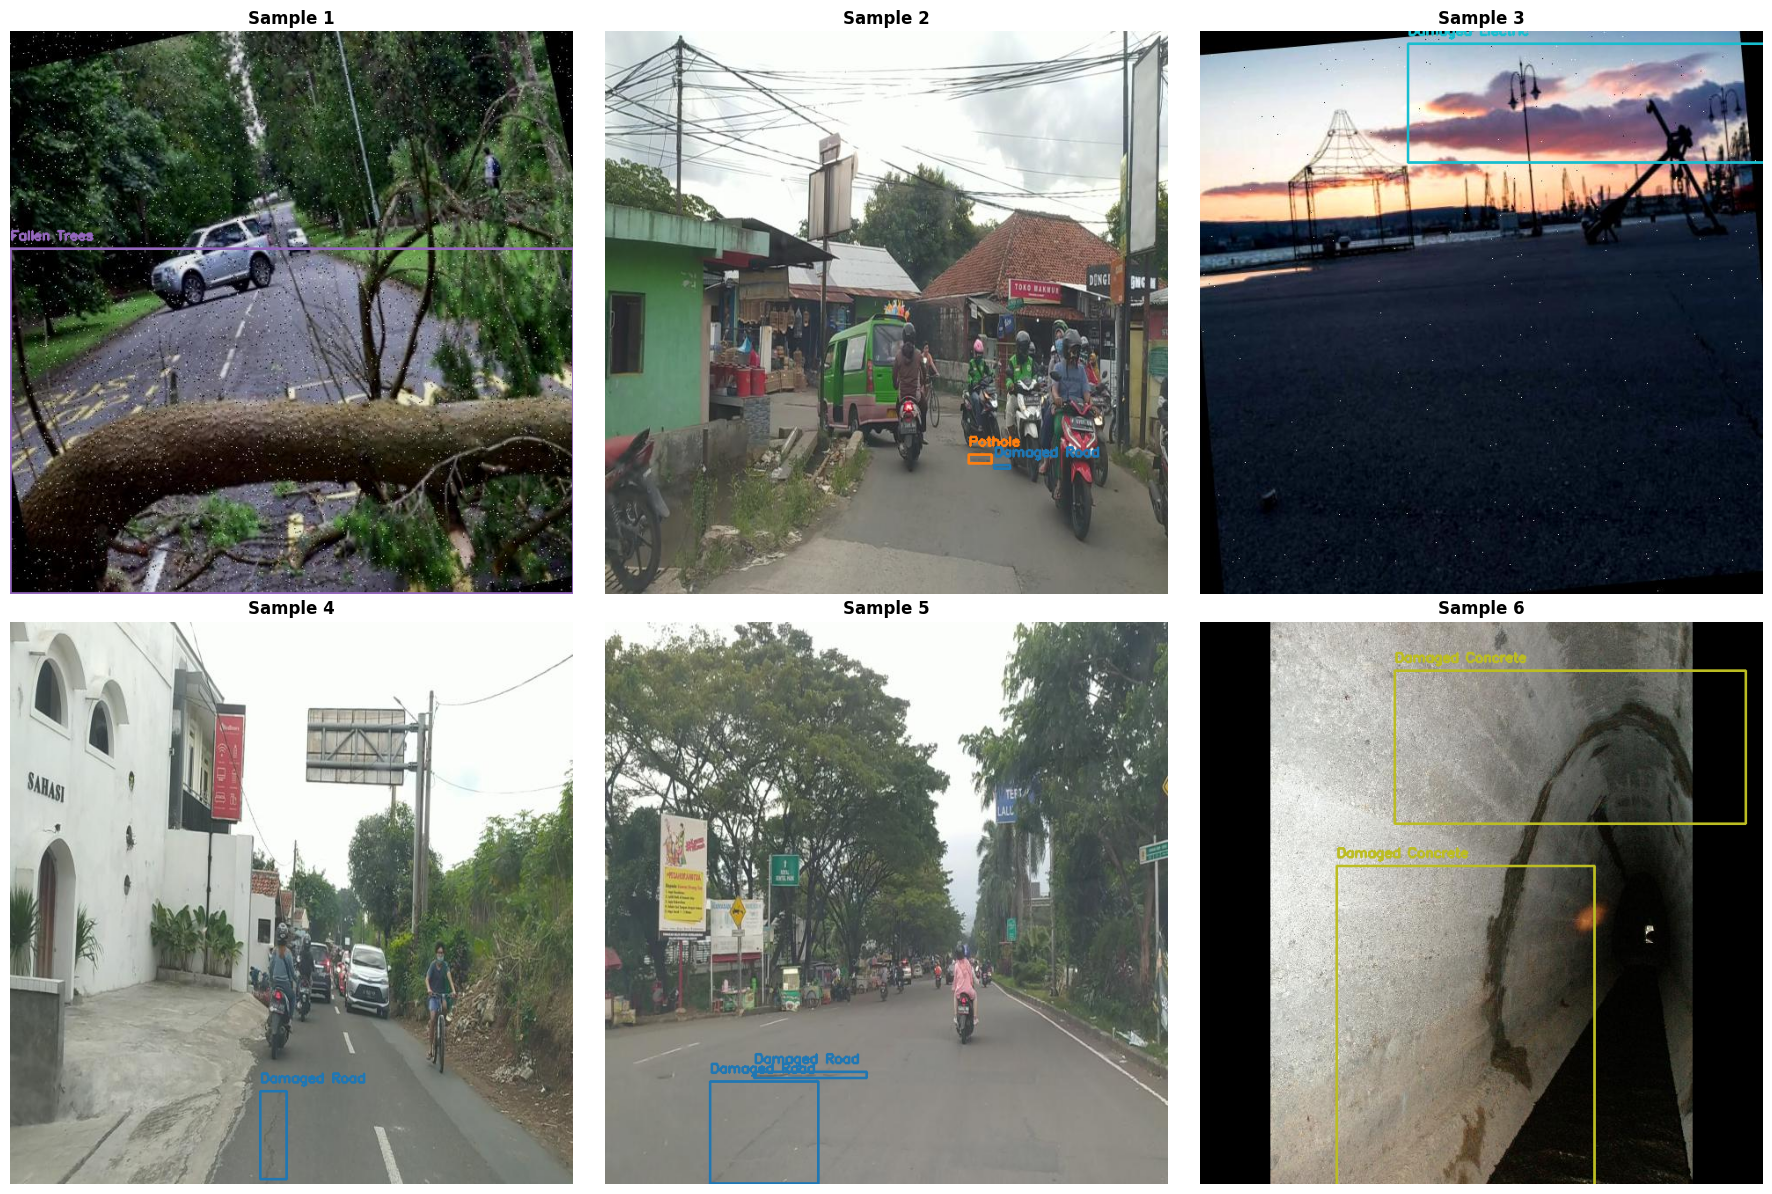

In [6]:
class_names = {
    0: "Damaged Road",
    1: "Pothole",
    2: "Illegal Parking",
    3: "Broken Road Sign",
    4: "Fallen Trees",
    5: "Littering/Garbage",
    6: "Vandalism",
    7: "Dead Animal",
    8: "Damaged Concrete",
    9: "Damaged Electric"
}

# Initialize analyzer
analyzer = YOLODatasetAnalyzer(dataset_path, class_names)

# Run analysis
print("\n🔍 Analyzing dataset...")
class_counts, bbox_counts, bbox_sizes = analyzer.analyze_dataset()

print("\n📊 Visualizing analysis...")
stats = analyzer.visualize_analysis()

print("\n🖼️ Visualizing samples...")
analyzer.visualize_samples(num_samples=6)

In [7]:
print("\n🔧 Reorganizing dataset structure for YOLO...")

# Define class mapping
class_mapping = {
    'Potholes and RoadCracks': 0,
    'IllegalParking': 2,
    'DamagedRoadSigns': 3,
    'FallenTrees': 4,
    'Garbage': 5,
    'Graffitti': 6,
    'DeadAnimalsPollution': 7,
    'Damaged concrete structures': 8,
    'DamagedElectricalPoles': 9,
}

# Create organized dataset structure in working directory
organized_path = KAGGLE_WORKING / 'organized_dataset'
for split in ['train', 'valid', 'test']:
    (organized_path / split / 'images').mkdir(parents=True, exist_ok=True)
    (organized_path / split / 'labels').mkdir(parents=True, exist_ok=True)

print("📁 Created organized dataset structure")



🔧 Reorganizing dataset structure for YOLO...
📁 Created organized dataset structure


In [8]:
def reorganize_dataset(source_path, dest_path, class_mapping):
    """Reorganize dataset from class-separated folders to unified structure"""
    stats = {
        'train': {'images': 0, 'labels': 0},
        'valid': {'images': 0, 'labels': 0},
        'test': {'images': 0, 'labels': 0}
    }

    source_path = Path(source_path)
    dest_path = Path(dest_path)

    for class_folder_name, class_id in class_mapping.items():
        print(f"\n📦 Processing: {class_folder_name} (Class ID: {class_id})")

        class_folders = list(source_path.rglob(class_folder_name))

        if not class_folders:
            print(f"  ⚠️ Warning: Folder '{class_folder_name}' not found")
            continue

        class_folder = max(class_folders, key=lambda p: len(p.parts))

        for split in ['train', 'valid', 'test']:
            split_path = class_folder / split

            if not split_path.exists():
                print(f"  ⚠️ {split} folder not found")
                continue

            images_path = split_path / 'images'
            labels_path = split_path / 'labels'

            if images_path.exists():
                image_files = list(images_path.glob('*.[jp][pn]g')) + \
                             list(images_path.glob('*.jpeg'))

                for img_file in image_files:
                    new_name = f"{class_folder_name.replace(' ', '_')}_{img_file.name}"
                    dest_img = dest_path / split / 'images' / new_name

                    shutil.copy2(img_file, dest_img)
                    stats[split]['images'] += 1

                    label_file = labels_path / (img_file.stem + '.txt')
                    if label_file.exists():
                        dest_label = dest_path / split / 'labels' / \
                                    (new_name.rsplit('.', 1)[0] + '.txt')

                        with open(label_file, 'r') as f:
                            lines = f.readlines()

                        updated_lines = []
                        for line in lines:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                parts[0] = str(class_id)
                                updated_lines.append(' '.join(parts) + '\n')

                        with open(dest_label, 'w') as f:
                            f.writelines(updated_lines)

                        stats[split]['labels'] += 1

                print(f"  ✅ {split}: {len(image_files)} images")

    return stats

In [9]:
stats = reorganize_dataset(dataset_path, organized_path, class_mapping)


📦 Processing: Potholes and RoadCracks (Class ID: 0)
  ✅ train: 5667 images
  ✅ valid: 1219 images
  ✅ test: 369 images

📦 Processing: IllegalParking (Class ID: 2)
  ✅ train: 57 images
  ✅ valid: 3 images
  ✅ test: 7 images

📦 Processing: DamagedRoadSigns (Class ID: 3)
  ✅ train: 2267 images
  ✅ valid: 43 images
  ✅ test: 39 images

📦 Processing: FallenTrees (Class ID: 4)
  ✅ train: 8500 images
  ✅ valid: 982 images
  ✅ test: 1632 images

📦 Processing: Garbage (Class ID: 5)
  ✅ train: 3133 images
  ✅ valid: 660 images
  ✅ test: 337 images

📦 Processing: Graffitti (Class ID: 6)
  ✅ train: 1704 images
  ✅ valid: 214 images
  ✅ test: 210 images

📦 Processing: DeadAnimalsPollution (Class ID: 7)
  ✅ train: 172 images
  ✅ valid: 32 images
  ✅ test: 16 images

📦 Processing: Damaged concrete structures (Class ID: 8)
  ✅ train: 9315 images
  ✅ valid: 1228 images
  ✅ test: 1222 images

📦 Processing: DamagedElectricalPoles (Class ID: 9)
  ✅ train: 7271 images
  ✅ valid: 513 images
  ✅ test: 328 i

In [10]:
data_yaml_content = {
    'path': str(organized_path),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 10,
    'names': {
        0: 'Damaged Road issues',
        1: 'Pothole Issues',
        2: 'Illegal Parking Issues',
        3: 'Broken Road Sign Issues',
        4: 'Fallen trees',
        5: 'Littering/Garbage on Public Places',
        6: 'Vandalism Issues',
        7: 'Dead Animal Pollution',
        8: 'Damaged concrete structures',
        9: 'Damaged Electric wires and poles'
    }
}

yaml_path = organized_path / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False, default_flow_style=False)

print(f"\n✅ Created data.yaml at {yaml_path}")
print("\n📄 Content:")
with open(yaml_path, 'r') as f:
    print(f.read())

# Verify structure
print("\n🔍 Verifying organized dataset structure:")
for split in ['train', 'valid', 'test']:
    img_count = len(list((organized_path / split / 'images').glob('*')))
    lbl_count = len(list((organized_path / split / 'labels').glob('*.txt')))
    print(f"{split}: {img_count} images, {lbl_count} labels")


✅ Created data.yaml at /kaggle/working/organized_dataset/data.yaml

📄 Content:
path: /kaggle/working/organized_dataset
train: train/images
val: valid/images
test: test/images
nc: 10
names:
  0: Damaged Road issues
  1: Pothole Issues
  2: Illegal Parking Issues
  3: Broken Road Sign Issues
  4: Fallen trees
  5: Littering/Garbage on Public Places
  6: Vandalism Issues
  7: Dead Animal Pollution
  8: Damaged concrete structures
  9: Damaged Electric wires and poles


🔍 Verifying organized dataset structure:
train: 38086 images, 38084 labels
valid: 4894 images, 4894 labels
test: 4160 images, 4160 labels


In [11]:
print("\n🚀 Starting YOLOv12 Training...")

# Initialize YOLOv12 model
model = YOLO("yolo12n.pt")  # Nano version for faster training

# Train the model
results = model.train(
    data=yaml_path,
    epochs=100,  # Increase for better results
    imgsz=640,
    batch=64,
    name='urban_issues_detector',
    patience=5,
    save=True,
    plots=True,
    val=True,
    project=str(KAGGLE_WORKING / 'runs'),
    device=[0, 1] # using 2 devices
)

print("\n✅ Training completed!")


🚀 Starting YOLOv12 Training...
Ultralytics 8.3.205 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/organized_dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=urban_is

######################################################################## 100.0%


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1375.4±722.9 MB/s, size: 53.0 KB)
train: Scanning /kaggle/working/organized_dataset/train/labels... 38084 images, 356 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38086/38086 1.2Kit/s 32.4s
train: /kaggle/working/organized_dataset/train/images/Damaged_concrete_structures_1692177626170_jpg.rf.0405b6db52c987df8de37893a39380f7.jpg: 1 duplicate labels removed
train: /kaggle/working/organized_dataset/train/images/Damaged_concrete_structures_dacl10k_v2_train_0518_jpg.rf.4f5bd61589586a072d7e3a0a2582f65d.jpg: 1 duplicate labels removed
train: /kaggle/working/organized_dataset/train/images/Damaged_concrete_structures_dacl10k_v2_train_0618_jpg.rf.dfe48b7f5fe880584d9ea2fb92243408.jpg: 1 duplicate labels removed
train: /kaggle/working/organized_dataset/train/images/Damaged_concrete_structures_dacl10k_v2_train_0619_jpg.rf.a39b57df2e358a99d23b19b9350d0ea4.jpg: 1 duplicate labels removed
train: /kaggle/working/organized_dataset/tra

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       4894      15731      0.652      0.598      0.637      0.425
   Damaged Road issues       1219       3165      0.661      0.522      0.596      0.288
Illegal Parking Issues          3         13     0.0609     0.0769     0.0163    0.00675
Broken Road Sign Issues         41         41      0.863      0.925      0.902      0.667
          Fallen trees        982       1237      0.875      0.769      0.845      0.601
Littering/Garbage on Public Places        660       1175      0.681       0.67      0.712      0.485
      Vandalism Issues        214        413       0.68      0.721      0.774       0.59
 Dead Animal Pollution         25         25      0.682       0.72      0.784      0.427
Damaged concrete structures       1225       9113      0.571      0.199      0.271      0.146
Damaged Electric wires and poles        462        549      0.796      0.783      0.833      0.612
Speed: 0.2ms preprocess, 4.0ms inference, 0.0ms loss, 0.9ms postprocess per image



📊 Evaluating model...
Ultralytics 8.3.205 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,558,678 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1739.8±386.1 MB/s, size: 76.1 KB)
val: Scanning /kaggle/working/organized_dataset/valid/labels.cache... 4894 images, 63 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4894/4894 7.8Mit/s 0.0s
val: /kaggle/working/organized_dataset/valid/images/Damaged_concrete_structures_dacl10k_v2_train_1079_jpg.rf.7101a4f6ff6310b343f4c7c3192e593e.jpg: 1 duplicate labels removed
val: /kaggle/working/organized_dataset/valid/images/Damaged_concrete_structures_dacl10k_v2_train_1415_jpg.rf.5baa774e055cd0a042a1467f1c4f3352.jpg: 3 duplicate labels removed
val: /kaggle/working/organized_dataset/valid/images/Damaged_concrete_structures_dacl10k_v2_train_1560_jpg.rf.5a50b63f642b058f2f2524b2807b4032.jpg: 1 duplicate labels removed
val: /kaggle/working/organized_dataset/valid/images/

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       4894      15731       0.65      0.599      0.637      0.425
   Damaged Road issues       1219       3165      0.659      0.524      0.597      0.288
Illegal Parking Issues          3         13     0.0607     0.0769     0.0163    0.00675
Broken Road Sign Issues         41         41      0.863      0.925      0.903      0.668
          Fallen trees        982       1237      0.873       0.77      0.845      0.601
Littering/Garbage on Public Places        660       1175      0.676      0.669      0.711      0.485
      Vandalism Issues        214        413      0.679      0.724      0.773      0.589
 Dead Animal Pollution         25         25       0.68       0.72      0.784      0.427
Damaged concrete structures       1225       9113      0.567        0.2      0.271      0.146
Damaged Electric wires and poles        462        549      0.797      0.785      0.833      0.612
Speed: 0.2ms preprocess, 6.0ms inference, 0.0ms loss, 0.9ms postprocess per image


/tmp/ipykernel_19/2949907337.py:53: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(122, projection='polar')


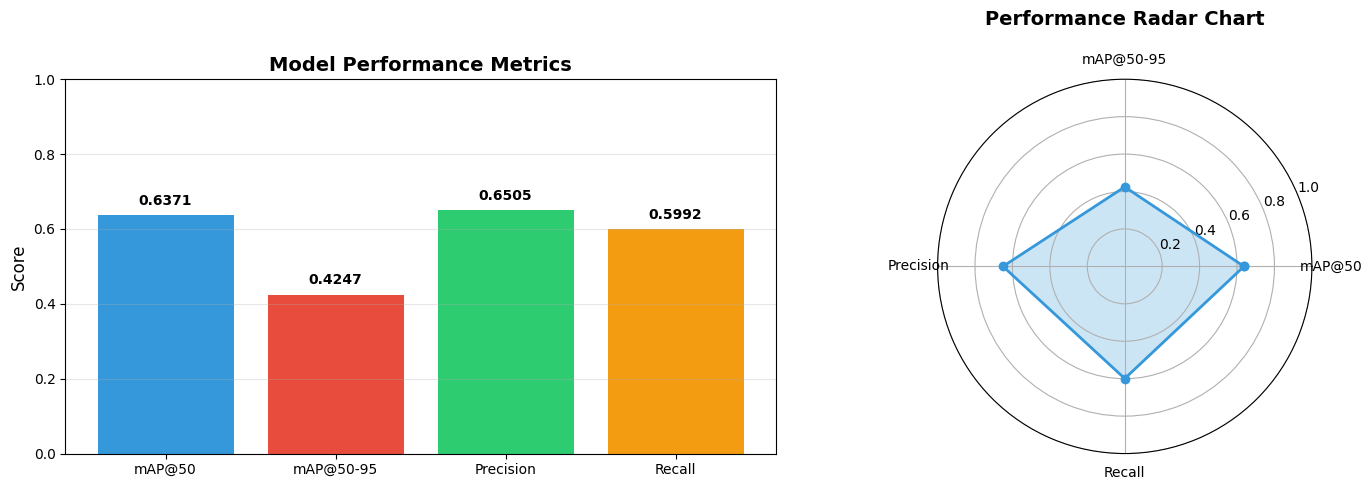

In [12]:
print("\n📊 Evaluating model...")

# Validate the model
metrics = model.val()

# Extract metrics
map50 = metrics.box.map50
map50_95 = metrics.box.map
precision = metrics.box.mp
recall = metrics.box.mr

# Print metrics
print("\n" + "="*50)
print("📈 MODEL PERFORMANCE METRICS")
print("="*50)
print(f"mAP@50:     {map50:.4f}")
print(f"mAP@50-95:  {map50_95:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print("="*50)

# Create metrics DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    'Value': [map50, map50_95, precision, recall]
})

print("\n📊 Metrics DataFrame:")
print(metrics_df)

# Visualize metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
axes[0].bar(metrics_df['Metric'], metrics_df['Value'], 
           color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_df['Value']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Radar chart
categories = metrics_df['Metric'].tolist()
values = metrics_df['Value'].tolist()
values += values[:1]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax = plt.subplot(122, projection='polar')
ax.plot(angles, values, 'o-', linewidth=2, color='#3498db')
ax.fill(angles, values, alpha=0.25, color='#3498db')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.grid(True)

plt.tight_layout()
plt.savefig(KAGGLE_WORKING / 'model_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print("\n📊 Training Results Visualization...")

results_path = KAGGLE_WORKING / 'runs' / 'detect' / 'urban_issues_detector'
if results_path.exists():
    print(f"Results saved in: {results_path}")

    plots = ['results.png', 'confusion_matrix.png', 'F1_curve.png', 'PR_curve.png']
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.ravel()

    for idx, plot_name in enumerate(plots):
        plot_path = results_path / plot_name
        if plot_path.exists():
            img = plt.imread(plot_path)
            axes[idx].imshow(img)
            axes[idx].axis('off')
            axes[idx].set_title(plot_name.replace('.png', '').replace('_', ' ').title(),
                              fontsize=14, fontweight='bold')
        else:
            axes[idx].text(0.5, 0.5, f'{plot_name} not found',
                          ha='center', va='center', fontsize=12)
            axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(KAGGLE_WORKING / 'training_results.png', dpi=300, bbox_inches='tight')
    plt.show()


📊 Training Results Visualization...
